# Student Name: Alexander Tewobola

# Student ID: 004006995



## DATASET OVERVIEW

TITLE : Predicting Income Levels Using Demographic Patterns

SOURCE: [Adult Income Dataset](https://www.kaggle.com/datasets/anaghakp/adult-income-census)

DESCRIPTION: This dataset provides data on the income of a group of people older than 16 years of age. The objective of this dataset is to predict whether a person's annual income exceeds $50,000, and factors influencing the value.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('adult_income.csv')
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income
0,17,Private,148522,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
1,17,Private,93235,12th,8,Never-married,occupation,Own-child,White,Female,United-States,<=50K
2,17,Private,184924,9th,5,Never-married,occupation,Own-child,White,Male,United-States,<=50K
3,17,Private,116626,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
4,17,Private,209949,11th,7,Never-married,occupation,Own-child,White,Female,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
31942,90,?,175444,7th-8th,4,Separated,?,Not-in-family,White,Female,United-States,<=50K
31943,90,Federal-gov,195433,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
31944,90,Private,47929,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,<=50K
31945,90,?,313986,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,United-States,>50K


In [5]:
df.shape

(31947, 12)

In [6]:
df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income
0,17,Private,148522,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
1,17,Private,93235,12th,8,Never-married,occupation,Own-child,White,Female,United-States,<=50K
2,17,Private,184924,9th,5,Never-married,occupation,Own-child,White,Male,United-States,<=50K
3,17,Private,116626,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
4,17,Private,209949,11th,7,Never-married,occupation,Own-child,White,Female,United-States,<=50K


In [7]:
df.tail(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income
31942,90,?,175444,7th-8th,4,Separated,?,Not-in-family,White,Female,United-States,<=50K
31943,90,Federal-gov,195433,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
31944,90,Private,47929,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,<=50K
31945,90,?,313986,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,United-States,>50K
31946,90,Private,313749,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,United-States,<=50K


In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'native.country', 'income'],
      dtype='object')

In [9]:
df.info()
# I do not think any columns necessarily need to be converted from one type to another. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31947 entries, 0 to 31946
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             31947 non-null  int64 
 1   workclass       31947 non-null  object
 2   fnlwgt          31947 non-null  int64 
 3   education       31947 non-null  object
 4   education.num   31947 non-null  int64 
 5   marital.status  31947 non-null  object
 6   occupation      31947 non-null  object
 7   relationship    31947 non-null  object
 8   race            31947 non-null  object
 9   sex             31947 non-null  object
 10  native.country  31947 non-null  object
 11  income          31947 non-null  object
dtypes: int64(3), object(9)
memory usage: 2.9+ MB


In [10]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
native.country    object
income            object
dtype: object

In [11]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
native.country    0
income            0
dtype: int64

In [12]:
df.describe()

,age,fnlwgt,education.num
count,31947.000000,3.194700e+04,31947.000000
mean,38.570695,1.897319e+05,10.071149
std,13.646280,1.057567e+05,2.561430
min,17.000000,1.228500e+04,1.000000
25%,28.000000,1.176275e+05,9.000000
50%,37.000000,1.783120e+05,10.000000
75%,48.000000,2.374535e+05,12.000000
max,90.000000,1.484705e+06,16.000000


##### The mean gives a central value of the data. For this dataset the mean for age is 38, which means majority of the people are around 38 years of age. The min is the smallest value in the dataset and max is the largest. The standard deviation (std) shows how spread out the data is from the mean. Low std means the values are close to the mean and high std means the values are more spread out. 

##### Analyzing for this dataset, The average age is 38, with values ranging from 17 to 90, indicating a wide age range. The relatively high standard deviation suggests there is significant variability in ages within the dataset.

In [13]:
print(df['age'].mean())

38.5706952139481


##### Handling missing values 

In [14]:
df = pd.read_csv('adult_income.csv', na_values= '?')
df.isnull().sum()

age                  0
workclass         1778
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1785
relationship         0
race                 0
sex                  0
native.country      25
income               0
dtype: int64

In [15]:
df.fillna("Unknown", inplace=True)
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income
0,17,Private,148522,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
1,17,Private,93235,12th,8,Never-married,occupation,Own-child,White,Female,United-States,<=50K
2,17,Private,184924,9th,5,Never-married,occupation,Own-child,White,Male,United-States,<=50K
3,17,Private,116626,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
4,17,Private,209949,11th,7,Never-married,occupation,Own-child,White,Female,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
31942,90,Unknown,175444,7th-8th,4,Separated,Unknown,Not-in-family,White,Female,United-States,<=50K
31943,90,Federal-gov,195433,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
31944,90,Private,47929,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States,<=50K
31945,90,Unknown,313986,HS-grad,9,Married-civ-spouse,Unknown,Husband,White,Male,United-States,>50K


In [16]:
df['occupation'].value_counts()

occupation
Craft-repair         3838
Prof-specialty       3732
Exec-managerial      3696
Adm-clerical         3595
Sales                3388
Other-service        3148
Machine-op-inspct    1902
Unknown              1785
Transport-moving     1500
occupation           1462
Handlers-cleaners    1317
Farming-fishing       957
Tech-support          861
Protective-serv       617
Priv-house-serv       141
Armed-Forces            8
Name: count, dtype: int64

In [17]:
df['occupation'] = df['occupation'].replace('occupation', np.nan)

In [18]:
df['occupation'] = df['occupation'].fillna('Unknown')

In [19]:
df['occupation'].value_counts()

occupation
Craft-repair         3838
Prof-specialty       3732
Exec-managerial      3696
Adm-clerical         3595
Sales                3388
Unknown              3247
Other-service        3148
Machine-op-inspct    1902
Transport-moving     1500
Handlers-cleaners    1317
Farming-fishing       957
Tech-support          861
Protective-serv       617
Priv-house-serv       141
Armed-Forces            8
Name: count, dtype: int64

In [20]:
(df == '?').sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
native.country    0
income            0
dtype: int64

In [21]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
native.country    0
income            0
dtype: int64

In [22]:
[df.duplicated()]

[0        False
 1        False
 2        False
 3        False
 4        False
          ...  
 31942    False
 31943    False
 31944    False
 31945    False
 31946    False
 Length: 31947, dtype: bool]

###### Workclass, occupation and native.country columns have missing data.

###### They can affect analysis in the following ways:

    - if they are just dropped, it could change the whole data
    - can reduce dataset size
    - affect conclusions negatively

In [23]:
df['education'].unique()

array(['11th', '12th', '9th', '10th', '5th-6th', 'Some-college',
       'HS-grad', '7th-8th', 'Masters', 'Bachelors', 'Assoc-voc',
       'Assoc-acdm', 'Preschool', '1st-4th', 'Doctorate', 'Prof-school'],
      dtype=object)

In [24]:
# Adding a new column based on existing columns 

def education_level(ed):
    if ed in ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th','HS-grad']:
        return 'Low Education'
    elif ed in ['Some-college','Assoc-acdm','Assoc-voc']:
        return 'Medium Education'
    else:
        return 'High Education'

df['edu_income_group'] = df['education'].apply(education_level) # This new column (edu_income_group) represents how educational background could affect income. I grouped people with lower, education, medium education and higher education together to see how it plays a role. 

In [25]:
df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income,edu_income_group
0,17,Private,148522,11th,7,Never-married,Unknown,Own-child,White,Male,United-States,<=50K,Low Education
1,17,Private,93235,12th,8,Never-married,Unknown,Own-child,White,Female,United-States,<=50K,Low Education
2,17,Private,184924,9th,5,Never-married,Unknown,Own-child,White,Male,United-States,<=50K,Low Education
3,17,Private,116626,11th,7,Never-married,Unknown,Own-child,White,Male,United-States,<=50K,Low Education
4,17,Private,209949,11th,7,Never-married,Unknown,Own-child,White,Female,United-States,<=50K,Low Education


In [26]:
# To create filters to extract subsets of my data 
high_edu_high_income = df[
    (df['edu_income_group'] == 'High Education') & 
    (df['income'] == '>50K')
]
high_edu_high_income

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income,edu_income_group
3089,22,Private,233955,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Amer-Indian-Eskimo,Female,United-States,>50K,High Education
3090,22,Private,100345,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,United-States,>50K,High Education
3091,22,Private,195532,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,United-States,>50K,High Education
3835,23,Private,102942,Bachelors,13,Never-married,Unknown,Own-child,White,Female,United-States,>50K,High Education
3836,23,Self-emp-not-inc,258298,Bachelors,13,Never-married,Unknown,Own-child,White,Male,United-States,>50K,High Education
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31908,90,Private,87372,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,>50K,High Education
31910,90,Private,46786,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,United-States,>50K,High Education
31924,90,Private,51744,Masters,14,Never-married,Exec-managerial,Not-in-family,Black,Male,United-States,>50K,High Education
31933,90,Private,88991,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,England,>50K,High Education


In [27]:
low_edu_low_income = df[
    (df['edu_income_group'] == 'Low Education') & 
    (df['income'] == '>50K')
]
low_edu_low_income

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income,edu_income_group
944,19,Unknown,200790,12th,8,Married-civ-spouse,Unknown,Other-relative,White,Female,United-States,>50K,Low Education
1124,19,Private,323605,7th-8th,4,Never-married,Other-service,Not-in-family,White,Male,United-States,>50K,Low Education
2663,21,Private,548303,HS-grad,9,Married-civ-spouse,Prof-specialty,Own-child,White,Male,Mexico,>50K,Low Education
3087,22,Self-emp-not-inc,202920,HS-grad,9,Never-married,Unknown,Unmarried,White,Female,Dominican-Republic,>50K,Low Education
3329,22,State-gov,186634,12th,8,Never-married,Exec-managerial,Not-in-family,White,Male,United-States,>50K,Low Education
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31822,79,Unknown,163140,HS-grad,9,Married-civ-spouse,Unknown,Husband,White,Male,United-States,>50K,Low Education
31851,81,Private,177408,HS-grad,9,Married-civ-spouse,Unknown,Husband,White,Male,United-States,>50K,Low Education
31883,83,Self-emp-inc,240150,10th,6,Married-civ-spouse,Farming-fishing,Husband,White,Male,United-States,>50K,Low Education
31911,90,Private,175491,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,Ecuador,>50K,Low Education


In [28]:
# I created a subset which shows the amount of people with high education earning more than 50K and also created a subset of people with low education earning more than 50K
print("Number of people with high education earning >50K:", high_edu_high_income.shape[0])
print("Number of people with low education earning >50K:", low_edu_low_income.shape[0])

Number of people with high education earning >50K: 3803
Number of people with low education earning >50K: 1893


The above analysis directly shows that educational background plays a big role in people earning more than 50K a year

## To list the unique values and categories and which categorical variables seem important for analysis or grouping

In [29]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income',
       'edu_income_group'],
      dtype='object')


In [30]:
for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].unique()) # to show unique values in each categorical column

Column: workclass
['Private' 'Local-gov' 'Federal-gov' 'Unknown' 'Self-emp-not-inc'
 'Self-emp-inc' 'State-gov' 'Never-worked' 'Without-pay']
Column: education
['11th' '12th' '9th' '10th' '5th-6th' 'Some-college' 'HS-grad' '7th-8th'
 'Masters' 'Bachelors' 'Assoc-voc' 'Assoc-acdm' 'Preschool' '1st-4th'
 'Doctorate' 'Prof-school']
Column: marital.status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Widowed' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']
Column: occupation
['Unknown' 'Handlers-cleaners' 'Other-service' 'Adm-clerical' 'Sales'
 'Craft-repair' 'Farming-fishing' 'Prof-specialty' 'Tech-support'
 'Priv-house-serv' 'Machine-op-inspct' 'Protective-serv'
 'Transport-moving' 'Exec-managerial' 'Armed-Forces']
Column: relationship
['Own-child' 'Not-in-family' 'Other-relative' 'Husband' 'Unmarried' 'Wife']
Column: race
['White' 'Black' 'Amer-Indian-Eskimo' 'Asian-Pac-Islander' 'Other']
Column: sex
['Male' 'Female']
Column: native.country
['United-States' 'India' 'Mexico

## Grouping and Aggregation

In [31]:
grouped = df.groupby('edu_income_group')
mean_age = grouped['age'].mean()
mean_age

edu_income_group
High Education      40.841487
Low Education       38.807563
Medium Education    36.360350
Name: age, dtype: float64

###### From the grouped data, education level strongly influences income, with people in the high education group being older on average and more likely to earn >$50K. People in the medium education comes next, and lastly, people in the Low Education. 

## Initial Observations 

##### One of the most interesting insights from the Adult Income dataset is how strongly many factors such as education level, gender, workclass, and even relationship correlate with income. My focus was on Education Level, by grouping individuals into Low, Medium, and High Education categories, it becomes clear that those with higher education not only tend to be older on average but are also much more likely to earn over 50K annually. Additionally, examining categorical variables like occupation and marital status will reveal clear patterns in earnings, and show which groups are more likely to achieve higher income. Overall, the dataset highlights how factors such as education, work experience, and job type collectively influence financial outcomes, offering valuable perspectives for understanding socioeconomic trends and guiding career or policy decisions.

##### I noticed some columns that had question marks, and in the occupation column, I see just 'occupation' as the job, which also does not make sense. I am yet to work on this to find out why it is in the dataset in that way.

In [32]:
df.to_csv('adult_income_cleaned.csv', index=False)

In [33]:
df['occupation'].value_counts()

occupation
Craft-repair         3838
Prof-specialty       3732
Exec-managerial      3696
Adm-clerical         3595
Sales                3388
Unknown              3247
Other-service        3148
Machine-op-inspct    1902
Transport-moving     1500
Handlers-cleaners    1317
Farming-fishing       957
Tech-support          861
Protective-serv       617
Priv-house-serv       141
Armed-Forces            8
Name: count, dtype: int64

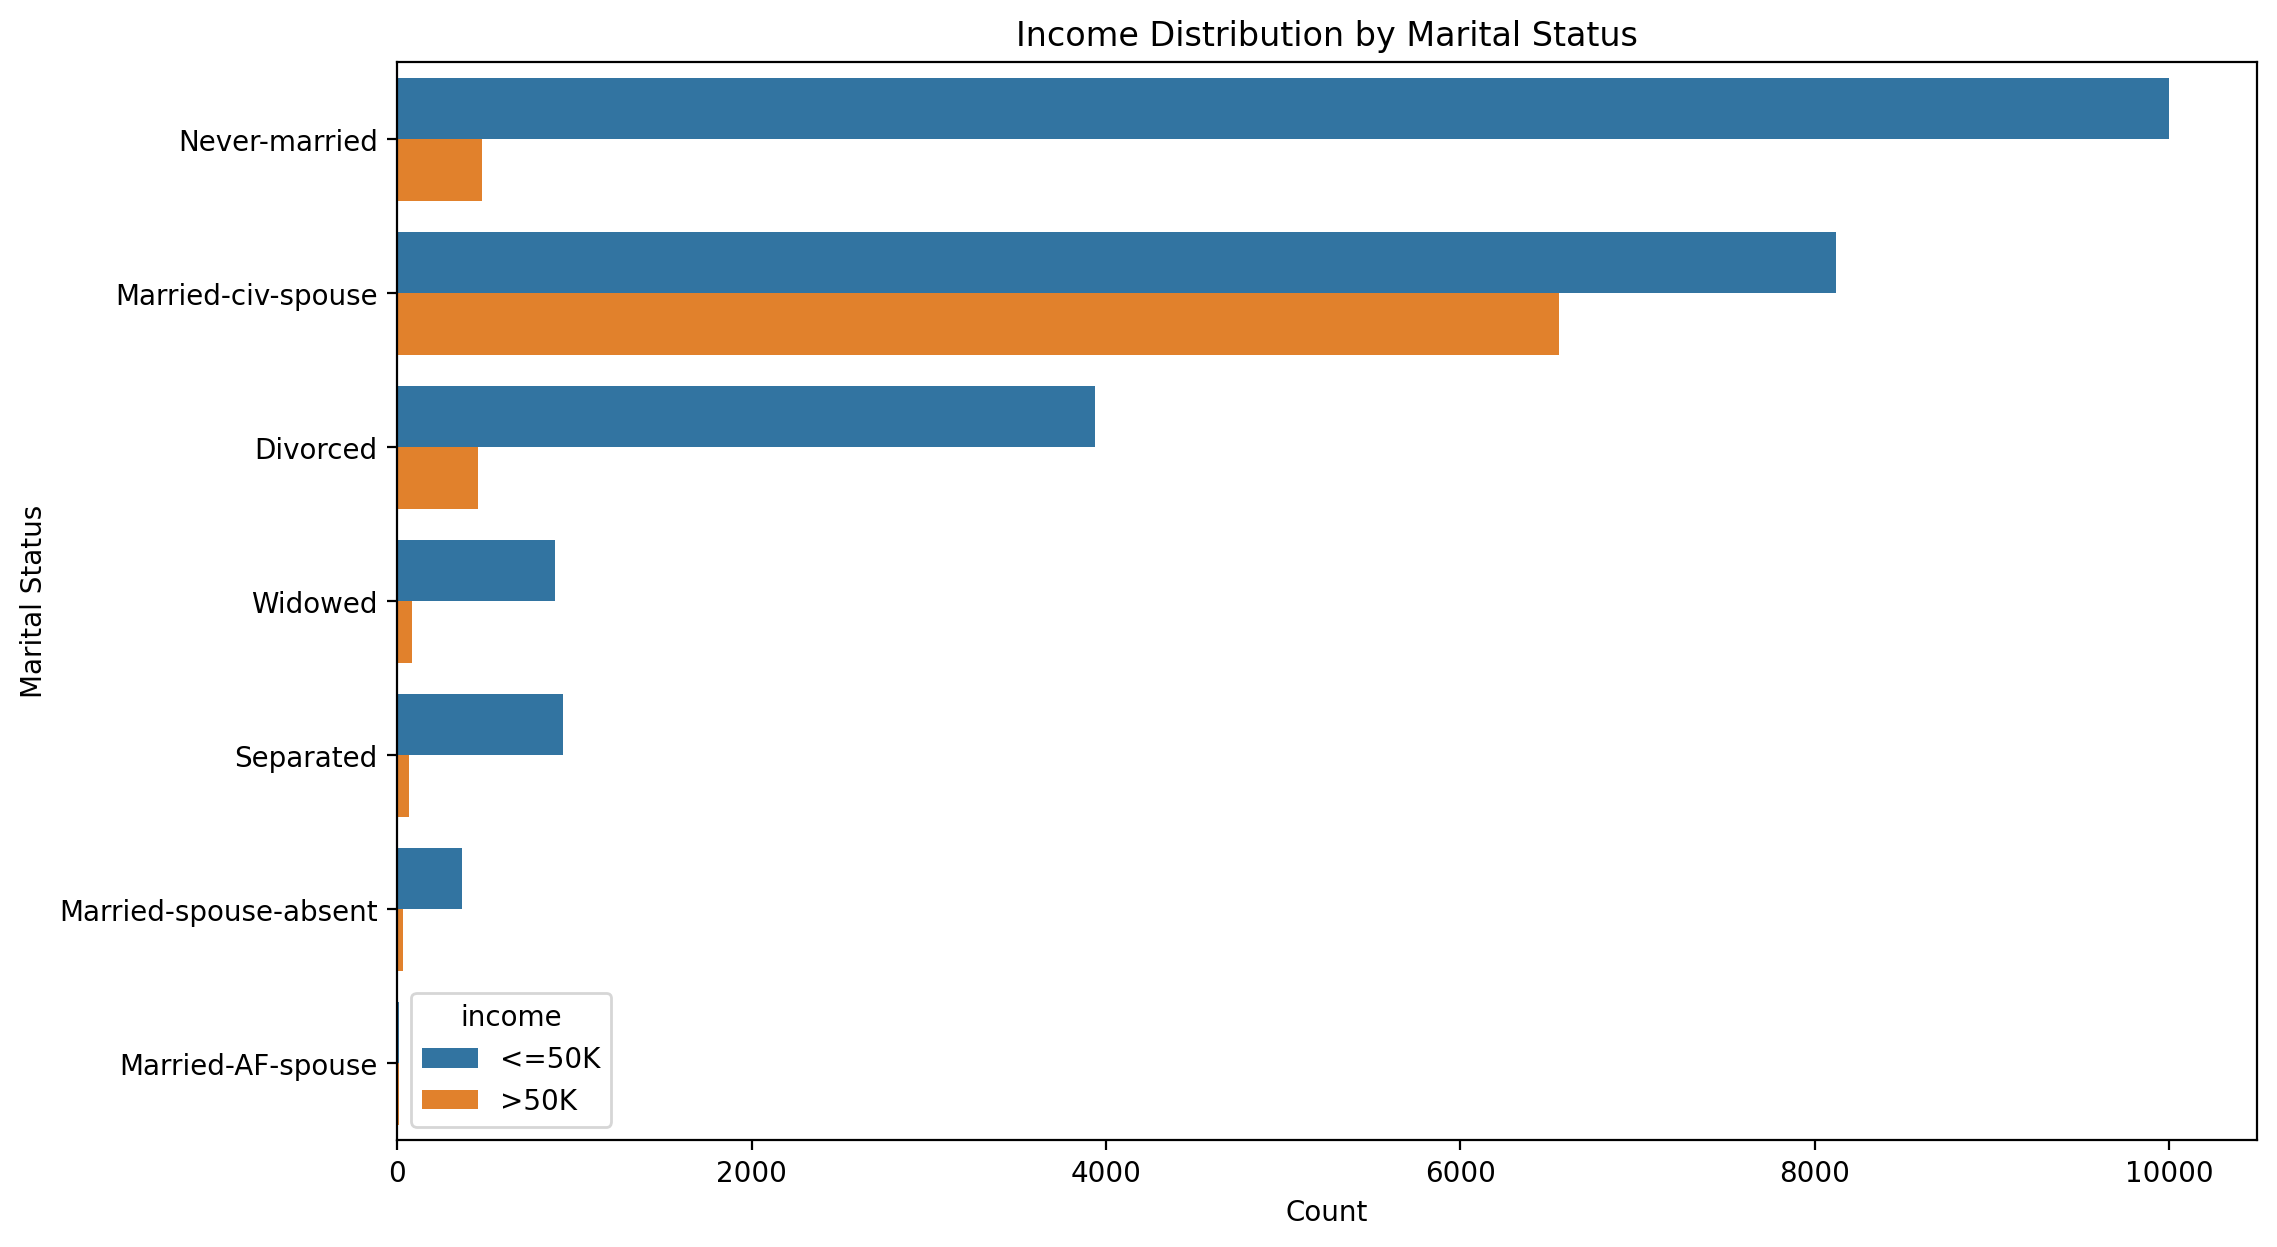

In [34]:
sns.countplot(y='marital.status', hue='income', data=df)
plt.title("Income Distribution by Marital Status")
plt.xlabel("Count")
plt.ylabel("Marital Status")
plt.savefig("Income Distribution by Marital Status.jpg")
plt.show()

##### Never married individuals are more likely to earn above 50K

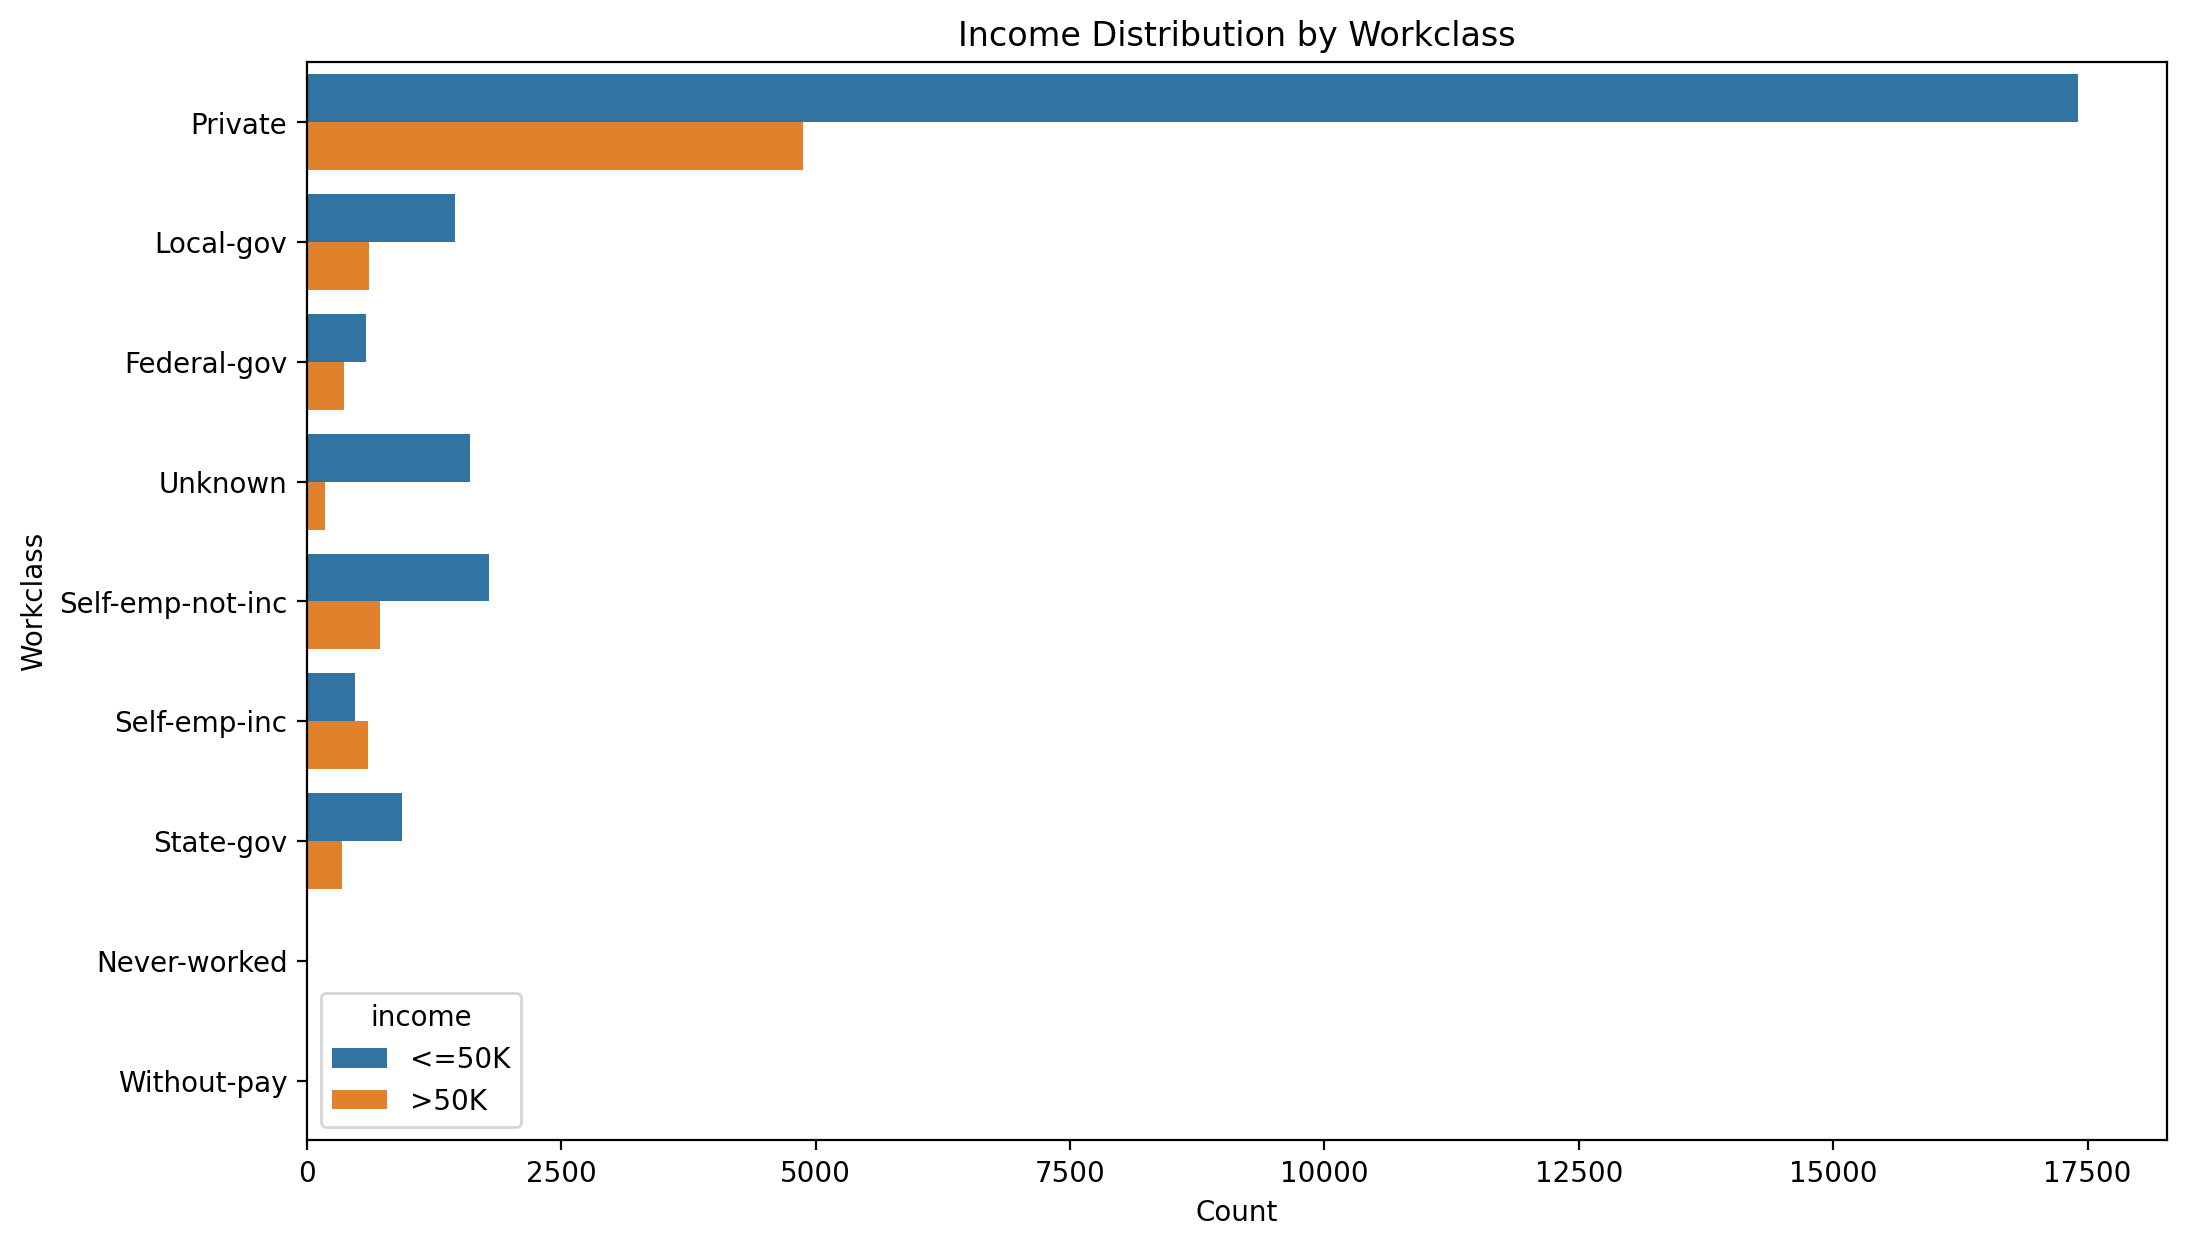

In [35]:
sns.countplot(y='workclass', hue='income', data=df)
plt.title("Income Distribution by Workclass")
plt.xlabel("Count")
plt.ylabel("Workclass")
plt.savefig("Income Distribution by Workclass.jpg")
plt.show()

##### People working in the private sector and self-employed roles tend to have a higher proportion of >50K earners compared to other work classes, while those with unknown ad other work classifications are more likely to earn ≤$50K.

In [0]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='age',
    hue='income',
    bins=20
)

plt.title("Age Distribution by Income")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("Age Distribution by Income.jpg")
plt.show()

##### The histogram shows how age values are distributed across income groups. The data is spread across a wide age range, but individuals earning above $50K are more concentrated in older age groups, while those earning less than or equal to $50K are more common among younger individuals. This suggests that age and experience plays a role in income differences.

In [0]:
avg_income_age = df.groupby('income')['age'].mean()

avg_income_age.plot(kind='bar')

plt.title("Average Age by Income Level")
plt.ylabel("Average Age")
plt.show()

##### The results show that individuals earning above $50K have a higher average age compared to those earning less than or equal to $50K.

In [0]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

##### The heatmap shows the correlation between numerical variables in the dataset. Most variables have weak correlations with each other, indicating that no single numerical factor strongly determines another.

In [0]:
df.to_csv('adult_income_cleaned.csv', index=False)